- importando as bibliotecas 

In [309]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("assets", exist_ok=True)
import sqlite3
sns.set(style="whitegrid")

In [166]:
conn = sqlite3.connect("data/database.sqlite")

In [167]:

dados = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)



In [168]:

matches = pd.read_sql("SELECT * FROM Match;", conn)

matches.shape
matches.head()


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


- Entendendo a estrutura da tabela Match

In [169]:
matches.columns

Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'],
      dtype='str', length=115)

In [170]:
# Subconjunto de colunas para análise das partidas
partidas_eda = matches[
    [
        "season",
        "date",
        "home_team_api_id",
        "away_team_api_id",
        "home_team_goal",
        "away_team_goal"
    ]
].copy()

partidas_eda


,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,2008/2009,2008-08-17 00:00:00,9987,9993,1,1
1,2008/2009,2008-08-16 00:00:00,10000,9994,0,0
2,2008/2009,2008-08-16 00:00:00,9984,8635,0,3
3,2008/2009,2008-08-17 00:00:00,9991,9998,5,0
4,2008/2009,2008-08-16 00:00:00,7947,9985,1,3
...,...,...,...,...,...,...
25974,2015/2016,2015-09-22 00:00:00,10190,10191,1,0
25975,2015/2016,2015-09-23 00:00:00,9824,10199,1,2
25976,2015/2016,2015-09-23 00:00:00,9956,10179,2,0
25977,2015/2016,2015-09-22 00:00:00,7896,10243,0,0


In [171]:
# conferindo valores unicos
partidas_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   season            25979 non-null  str  
 1   date              25979 non-null  str  
 2   home_team_api_id  25979 non-null  int64
 3   away_team_api_id  25979 non-null  int64
 4   home_team_goal    25979 non-null  int64
 5   away_team_goal    25979 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.2 MB


In [172]:
#Converter a coluna de data
partidas_eda['date'] = pd.to_datetime(partidas_eda['date'])
partidas_eda["ano"] = partidas_eda["date"].dt.year

- Gols totais das partidas

In [173]:
partidas_eda['gols_totais'] = (
    partidas_eda['home_team_goal'] +
    partidas_eda['away_team_goal']
)


Resultado das partidas

In [174]:
def resultado_partida(linha):
    if linha['home_team_goal'] > linha['away_team_goal']:
        return 'Vitoria mandante'
    elif linha['home_team_goal'] < linha['away_team_goal']:
        return 'Vitoria visitante'
    else:
        return 'Empate'
    

partidas_eda["resultado"] = partidas_eda.apply(
    resultado_partida, axis=1
)


In [175]:
partidas_eda.head()

,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,ano,gols_totais,resultado
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante


Distribuindo gols por partidas

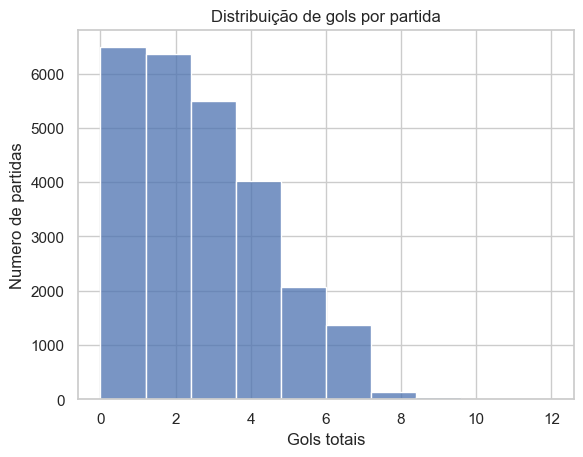

In [321]:
sns.histplot(partidas_eda['gols_totais'], bins=10)
plt.title('Distribuição de gols por partida')
plt.xlabel('Gols totais')
plt.ylabel('Numero de partidas')
plt.savefig("assets/distribuicao_gols_partida.png", dpi=150, bbox_inches="tight")
plt.show()

Distribuindo Resultados

In [177]:
partidas_eda['resultado'].value_counts(normalize= True)

resultado
Vitoria mandante     0.458717
Vitoria visitante    0.287386
Empate               0.253897
Name: proportion, dtype: float64

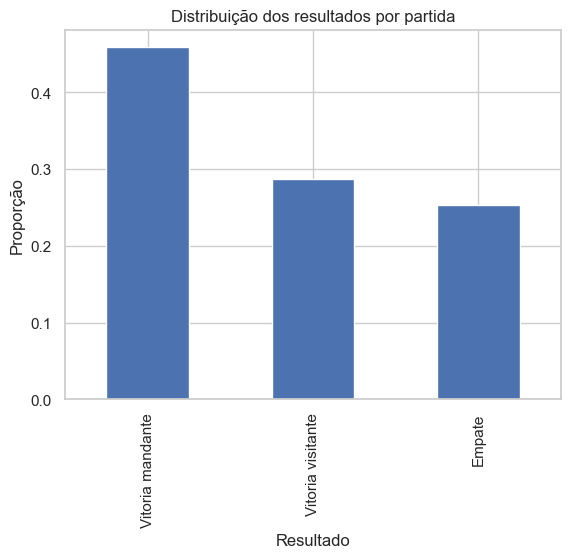

In [178]:
partidas_eda['resultado'].value_counts(
    normalize= True).plot(kind='bar')

plt.title('Distribuição dos resultados por partida')
plt.ylabel('Proporção')
plt.xlabel('Resultado')
plt.show()


In [179]:

partidas_eda = partidas_eda.rename(columns={
    "home_team_goal": "gols_mandante",
    "away_team_goal": "gols_visitante"
})


Mandante x Visitante gols

In [180]:
# Vendo quantos gols cada lado fez
partidas_eda[['gols_mandante', 'gols_visitante']].describe()

,gols_mandante,gols_visitante
count,25979.000000,25979.000000
mean,1.544594,1.160938
std,1.297158,1.142110
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,10.000000,9.000000


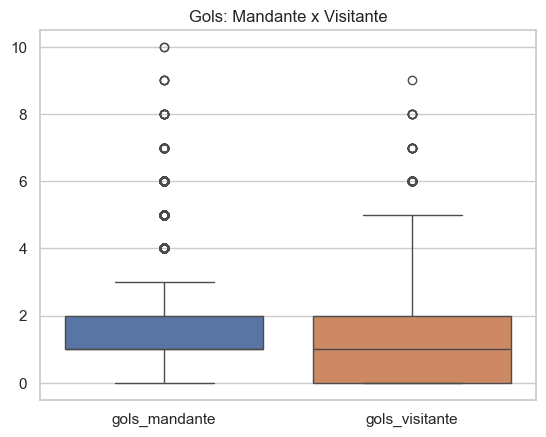

In [322]:
# comparando
sns.boxplot(
    data=partidas_eda[['gols_mandante', 'gols_visitante']]
)
plt.title('Gols: Mandante x Visitante')
plt.savefig("assets/mandante_x_visitante.png", dpi=150, bbox_inches="tight")
plt.show()

Analise temporal

In [182]:
# media de gols por temporada
media_gols_temporada = (
    partidas_eda.groupby('season')['gols_totais'].mean()
)
media_gols_temporada

season
2008/2009    2.607336
2009/2010    2.672446
2010/2011    2.683742
2011/2012    2.716460
2012/2013    2.772699
2013/2014    2.766821
2014/2015    2.675789
2015/2016    2.754660
Name: gols_totais, dtype: float64

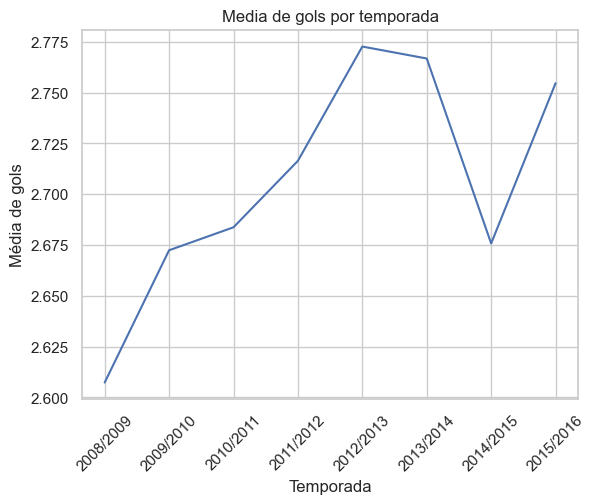

In [183]:
sns.lineplot(
    x=media_gols_temporada.index,
    y=media_gols_temporada.values
)
plt.title('Media de gols por temporada')
plt.xlabel('Temporada')
plt.ylabel('Média de gols')
plt.xticks(rotation=45)
plt.show()

Tabela de times

In [184]:
times = pd.read_sql("SELECT team_api_id, team_long_name FROM Team;",
                    conn)
times.head

<bound method NDFrame.head of      team_api_id      team_long_name
0           9987            KRC Genk
1           9993        Beerschot AC
2          10000    SV Zulte-Waregem
3           9994    Sporting Lokeren
4           9984   KSV Cercle Brugge
..           ...                 ...
294        10190       FC St. Gallen
295        10191             FC Thun
296         9777         Servette FC
297         7730  FC Lausanne-Sports
298         7896              Lugano

[299 rows x 2 columns]>

Mandante

In [185]:
partidas_times = partidas_eda.merge(
    times,
    left_on='home_team_api_id',
    right_on='team_api_id',
    how='left'
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_mandante"
})

partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id,time_mandante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH


Visitante

In [186]:

partidas_times = partidas_times.merge(
    times,
    left_on="away_team_api_id",
    right_on="team_api_id",
    how="left"
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_visitante"
})
partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id_x,time_mandante,team_api_id_y,time_visitante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk,9993,Beerschot AC
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem,9994,Sporting Lokeren
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge,8635,RSC Anderlecht
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent,9998,RAEC Mons
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH,9985,Standard de Liège


Gols marcados como mandante 

In [187]:
gols_mandante = (
    partidas_times.groupby('time_mandante')['gols_mandante'].sum().sort_values(ascending= False)
)
gols_mandante.head(10)

time_mandante
Real Madrid CF       505
FC Barcelona         495
Celtic               389
FC Bayern Munich     382
PSV                  370
Manchester City      365
Ajax                 360
FC Basel             344
Manchester United    338
Chelsea              333
Name: gols_mandante, dtype: int64

Gols sofridos como mandante

In [188]:
gols_sofridos_mandante = (partidas_times.groupby('time_mandante')['gols_visitante'].sum().sort_values()
)
gols_sofridos_mandante.head(10)

time_mandante
Amadora                         15
Angers SCO                      15
Uniao da Madeira                17
UD Las Palmas                   17
FC Ingolstadt 04                18
Watford                         19
Feirense                        19
Termalica Bruk-Bet Nieciecza    19
Middlesbrough                   20
Trofense                        21
Name: gols_visitante, dtype: int64

Saldo de gols como Mandante

In [189]:
ranking_mandante = (
    partidas_times.groupby('time_mandante')[['gols_mandante', 'gols_visitante']].sum())

ranking_mandante['saldo_gols_mandante'] = (
    ranking_mandante['gols_mandante'] - ranking_mandante['gols_visitante']
)

ranking_mandante.sort_values('saldo_gols_mandante', ascending=False).head()

,gols_mandante,gols_visitante,saldo_gols_mandante
time_mandante,,,
FC Barcelona,495,101,394
Real Madrid CF,505,147,358
Celtic,389,88,301
FC Bayern Munich,382,96,286
Ajax,360,78,282



### Conclusão Parcial

Nesta etapa foi realizada a análise exploratória inicial da base de dados,
com foco nas partidas e no desempenho dos times atuando como mandantes.
Foram identificados padrões de distribuição de gols, vantagem do mandante
e diferenças claras entre desempenho ofensivo e defensivo dos times.



- Análise dos times: força ofensiva e defensiva

Gols como mandante

In [190]:

gols_marcados_casa = (
    partidas_times.groupby('time_mandante')['gols_mandante']
    .sum()
)
gols_marcados_casa 


time_mandante
1. FC Kaiserslautern         37
1. FC Köln                  116
1. FC Nürnberg              108
1. FSV Mainz 05             171
AC Ajaccio                   64
                           ... 
Xerez Club Deportivo         20
Zagłębie Lubin              116
Zawisza Bydgoszcz            43
Évian Thonon Gaillard FC    105
Śląsk Wrocław               176
Name: gols_mandante, Length: 296, dtype: int64

- CRIANDO VITORIA COMO VARIAVEIS NUMERICAS

In [191]:
partidas_times['vitoria_mandante'] = (
    partidas_times['resultado'] == 'Vitoria mandante'
)

partidas_times['vitoria_visitante'] = (
    partidas_times['resultado'] == 'Vitoria visitante'
)

-  Vitórias como mandante

In [192]:
vitoria_mandante = (partidas_times.groupby('time_mandante')['vitoria_mandante']
                    .sum().sort_values(ascending=False))

vitoria_mandante.head(10)

time_mandante
FC Barcelona         131
Real Madrid CF       129
Celtic               120
Manchester United    116
Manchester City      113
FC Bayern Munich     109
PSV                  105
Juventus             105
Ajax                 103
FC Basel             103
Name: vitoria_mandante, dtype: int64

- Vitorias como visitantes

In [193]:
vitoria_visitante = (partidas_times.groupby('time_visitante')['vitoria_visitante']
                     .sum().sort_values(ascending=False))

vitoria_visitante.head(10)


time_visitante
FC Barcelona         103
Real Madrid CF        99
Celtic                98
Juventus              84
FC Bayern Munich      84
SL Benfica            83
FC Porto              81
Ajax                  78
FC Basel              77
Manchester United     76
Name: vitoria_visitante, dtype: int64

### Força Ofensiva

- Media de gols por time em casa e fora

In [194]:
gols_casa = partidas_times.groupby('time_mandante')['gols_mandante'].mean()
gols_fora = partidas_times.groupby('time_visitante')['gols_visitante'].mean()

media_gols_time = (gols_casa + gols_fora) / 2

media_gols_time = media_gols_time.sort_values(ascending=False)

media_gols_time.head(10)

time_mandante
FC Barcelona        2.792763
Real Madrid CF      2.773026
FC Bayern Munich    2.400735
PSV                 2.397059
Ajax                2.378676
SL Benfica          2.290323
Celtic              2.286184
FC Porto            2.181452
FC Basel            2.164336
Rangers             2.131579
dtype: float64

### Força Defensiva

In [195]:
gols_sofridos_casa = partidas_times.groupby('time_mandante')['gols_visitante'].mean()
gols_sofridos_fora = partidas_times.groupby('time_visitante')['gols_mandante'].mean()

media_gols_sofridos = (gols_sofridos_casa + gols_sofridos_fora) / 2
media_gols_sofridos = media_gols_sofridos.sort_values()
media_gols_sofridos.head(10)

time_mandante
FC Porto            0.649194
Celtic              0.733553
Rangers             0.743421
SL Benfica          0.750000
FC Barcelona        0.763158
FC Bayern Munich    0.775735
Juventus            0.830596
Sporting CP         0.842742
Legia Warszawa      0.850000
RSC Anderlecht      0.858491
dtype: float64

### Criando Métrica complete

In [196]:

mandante = partidas_times[['time_mandante', 'gols_mandante', 'gols_visitante']].copy()

mandante.columns = ['time', 'gols_feitos', 'gols_sofridos']

visitante = partidas_times[['time_visitante', 'gols_visitante', 'gols_mandante']].copy()

visitante.columns = ['time', 'gols_feitos', 'gols_sofridos']


- junta Ataque + Defesa

In [197]:

dados_times = pd.concat([mandante, visitante])

desempenho_times = dados_times.groupby('time').agg({
    'gols_feitos': 'mean',
    'gols_sofridos': 'mean'
})

desempenho_times = desempenho_times.sort_values(by='gols_feitos', ascending=False)

desempenho_times.head(10)


,gols_feitos,gols_sofridos
time,,
FC Barcelona,2.792763,0.763158
Real Madrid CF,2.773026,1.000000
FC Bayern Munich,2.400735,0.775735
PSV,2.397059,1.080882
Ajax,2.378676,0.867647
SL Benfica,2.290323,0.750000
Celtic,2.286184,0.733553
FC Porto,2.181452,0.649194
FC Basel,2.164336,1.087413


- Saldo médio

In [198]:
desempenho_times['saldo_medio'] = (
    desempenho_times['gols_feitos'] -
    desempenho_times['gols_sofridos']
)

desempenho_times = desempenho_times.sort_values(by='saldo_medio', ascending=False)

desempenho_times.head(10)

,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Barcelona,2.792763,0.763158,2.029605
Real Madrid CF,2.773026,1.000000,1.773026
FC Bayern Munich,2.400735,0.775735,1.625000
Celtic,2.286184,0.733553,1.552632
SL Benfica,2.290323,0.750000,1.540323
FC Porto,2.181452,0.649194,1.532258
Ajax,2.378676,0.867647,1.511029
Rangers,2.131579,0.743421,1.388158
PSV,2.397059,1.080882,1.316176


Text(0, 0.5, 'Gols marcados (maior = melhor ataque)')

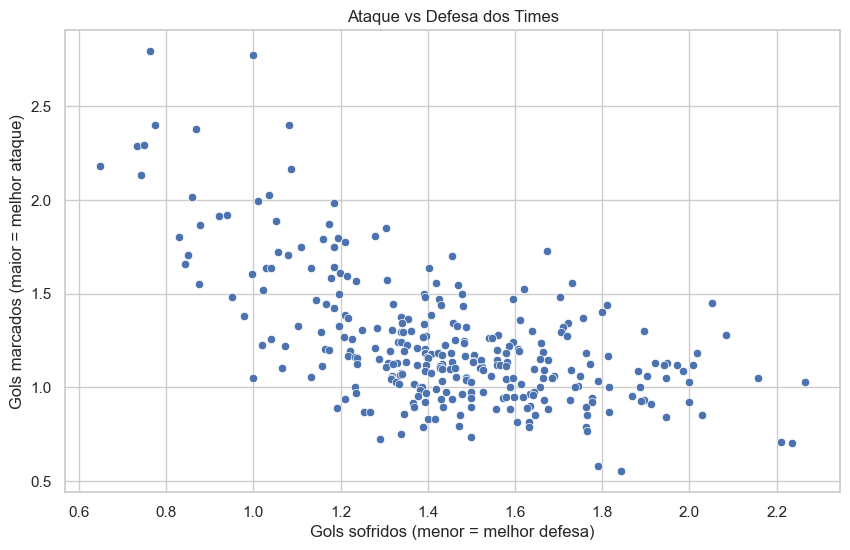

In [199]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=desempenho_times,
    x='gols_sofridos',
    y='gols_feitos'
)


plt.title('Ataque vs Defesa dos Times')
plt.xlabel('Gols sofridos (menor = melhor defesa)')
plt.ylabel('Gols marcados (maior = melhor ataque)')


- top 10 melhores

In [200]:

melhores_times = desempenho_times.sort_values(
    by='saldo_medio',
    ascending=False
)

melhores_times.head(10)


,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Barcelona,2.792763,0.763158,2.029605
Real Madrid CF,2.773026,1.000000,1.773026
FC Bayern Munich,2.400735,0.775735,1.625000
Celtic,2.286184,0.733553,1.552632
SL Benfica,2.290323,0.750000,1.540323
FC Porto,2.181452,0.649194,1.532258
Ajax,2.378676,0.867647,1.511029
Rangers,2.131579,0.743421,1.388158
PSV,2.397059,1.080882,1.316176


- Top 10 piores

In [201]:

piores_times = desempenho_times.sort_values(
    by='saldo_medio',
    ascending=True
)

piores_times.head(10)


,gols_feitos,gols_sofridos,saldo_medio
time,,,
FC Dordrecht,0.705882,2.235294,-1.529412
Pescara,0.710526,2.210526,-1.500000
AC Arles-Avignon,0.552632,1.842105,-1.289474
Tubize,1.029412,2.264706,-1.235294
Córdoba CF,0.578947,1.789474,-1.210526
FC Penafiel,0.852941,2.029412,-1.176471
Dunfermline Athletic,1.052632,2.157895,-1.105263
Cardiff City,0.842105,1.947368,-1.105263
Frosinone,0.921053,2.000000,-1.078947


### Player_Attributes

- Carregsndo e renomeando

In [202]:
atributos_jogadores = pd.read_sql("SELECT * FROM Player_Attributes", conn)

In [203]:
#inspeção inicial
atributos_jogadores.head()
atributos_jogadores.info()
atributos_jogadores.describe()

<class 'pandas.DataFrame'>
RangeIndex: 183978 entries, 0 to 183977
Data columns (total 42 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   183978 non-null  int64  
 1   player_fifa_api_id   183978 non-null  int64  
 2   player_api_id        183978 non-null  int64  
 3   date                 183978 non-null  str    
 4   overall_rating       183142 non-null  float64
 5   potential            183142 non-null  float64
 6   preferred_foot       183142 non-null  str    
 7   attacking_work_rate  180748 non-null  str    
 8   defensive_work_rate  183142 non-null  str    
 9   crossing             183142 non-null  float64
 10  finishing            183142 non-null  float64
 11  heading_accuracy     183142 non-null  float64
 12  short_passing        183142 non-null  float64
 13  volleys              181265 non-null  float64
 14  dribbling            183142 non-null  float64
 15  curve                181265 

,id,player_fifa_api_id,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,183978.00000,183978.000000,183978.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,181265.000000,...,181265.000000,183142.000000,183142.000000,183142.000000,181265.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000
mean,91989.50000,165671.524291,135900.617324,68.600015,73.460353,55.086883,49.921078,57.266023,62.429672,49.468436,...,57.873550,55.003986,46.772242,50.351257,48.001462,14.704393,16.063612,20.998362,16.132154,16.441439
std,53110.01825,53851.094769,136927.840510,7.041139,6.592271,17.242135,19.038705,16.488905,14.194068,18.256618,...,15.144086,15.546519,21.227667,21.483706,21.598778,16.865467,15.867382,21.452980,16.099175,17.198155
min,1.00000,2.000000,2625.000000,33.000000,39.000000,1.000000,1.000000,1.000000,3.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,45995.25000,155798.000000,34763.000000,64.000000,69.000000,45.000000,34.000000,49.000000,57.000000,35.000000,...,49.000000,45.000000,25.000000,29.000000,25.000000,7.000000,8.000000,8.000000,8.000000,8.000000
50%,91989.50000,183488.000000,77741.000000,69.000000,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,...,60.000000,57.000000,50.000000,56.000000,53.000000,10.000000,11.000000,12.000000,11.000000,11.000000
75%,137983.75000,199848.000000,191080.000000,73.000000,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,...,69.000000,67.000000,66.000000,69.000000,67.000000,13.000000,15.000000,15.000000,15.000000,15.000000
max,183978.00000,234141.000000,750584.000000,94.000000,97.000000,95.000000,97.000000,98.000000,97.000000,93.000000,...,97.000000,96.000000,96.000000,95.000000,95.000000,94.000000,93.000000,97.000000,96.000000,96.000000


Renomeando colunas importantes

In [204]:
atributos_jogadores = atributos_jogadores.rename(columns={
    'player_api_id' : 'id_jogador',
    'date' : 'data',
    'overall_rating' : 'nota_geral',
    'potential': 'potencial',
    'finishing': 'finalizacao',
    'short_passing': 'passe_curto',
    'long_passing': 'passe_longo',
    'dribbling': 'drible',
    'speed': 'velocidade'
})


Tratar data

In [205]:
atributos_jogadores['data'] = pd.to_datetime(atributos_jogadores['data'])

- Analise exploratória

<Axes: >

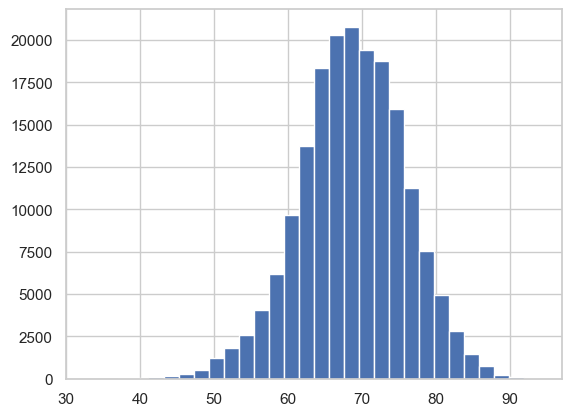

In [206]:
atributos_jogadores['nota_geral'].hist(bins=30)

- Top Melhores Jogadores

In [207]:
atributos_jogadores.sort_values(by='nota_geral', ascending= False).head(10)

,id,player_fifa_api_id,id_jogador,data,nota_geral,potencial,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
102496,102497,158023,30981,2013-02-15,94.0,97.0,left,high,medium,84.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102495,102496,158023,30981,2013-03-08,94.0,97.0,left,high,medium,84.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102494,102495,158023,30981,2013-03-22,94.0,97.0,left,high,medium,84.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102493,102494,158023,30981,2013-09-20,94.0,97.0,left,high,medium,84.0,...,90.0,76.0,25.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102499,102500,158023,30981,2011-08-30,94.0,96.0,left,high,medium,85.0,...,90.0,86.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102498,102499,158023,30981,2012-02-22,94.0,96.0,left,high,medium,85.0,...,90.0,78.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102497,102498,158023,30981,2012-08-31,94.0,96.0,left,high,medium,85.0,...,90.0,76.0,13.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102492,102493,158023,30981,2013-11-15,94.0,97.0,left,high,medium,84.0,...,90.0,76.0,25.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102491,102492,158023,30981,2014-04-25,94.0,97.0,left,medium,low,84.0,...,90.0,76.0,25.0,21.0,20.0,6.0,11.0,15.0,14.0,8.0
102484,102485,158023,30981,2015-09-21,94.0,95.0,left,medium,low,80.0,...,90.0,74.0,13.0,23.0,21.0,6.0,11.0,15.0,14.0,8.0


Evolução ao longo do tempo

<Axes: xlabel='data'>

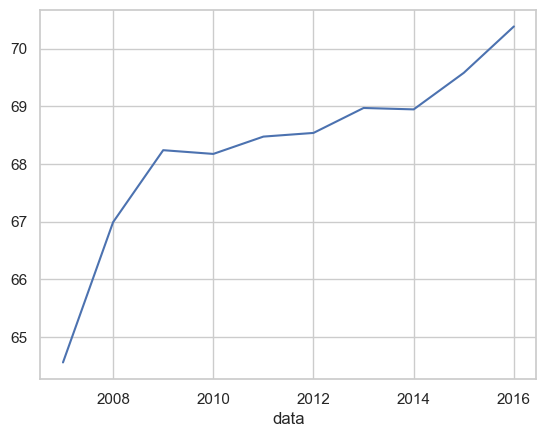

In [208]:
atributos_jogadores.groupby(atributos_jogadores['data'].dt.year)['nota_geral'].mean().plot()

Quais habilidades influenciam mais a nota:

In [209]:
# Correlação 
atributos_jogadores[['nota_geral', 'potencial', 'finalizacao', 'passe_curto', 'drible']].corr()

,nota_geral,potencial,finalizacao,passe_curto,drible
nota_geral,1.000000,0.766757,0.329298,0.458361,0.354324
potencial,0.766757,1.000000,0.286684,0.382605,0.338675
finalizacao,0.329298,0.286684,1.000000,0.579365,0.784659
passe_curto,0.458361,0.382605,0.579365,1.000000,0.787994
drible,0.354324,0.338675,0.784659,0.787994,1.000000


Reduzir a tabela deixando uma linha por jogador

In [210]:
media_jogadores = atributos_jogadores.groupby('id_jogador').mean(numeric_only=True)


- Analise final

melhores jogadores

In [211]:
media_jogadores.sort_values(by='nota_geral', ascending=False).head(10)

,id,player_fifa_api_id,nota_geral,potencial,crossing,finalizacao,heading_accuracy,passe_curto,volleys,drible,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
id_jogador,,,,,,,,,,,,,,,,,,,,,
30981,102495.5,158023.0,92.192308,95.230769,83.346154,92.230769,69.269231,88.807692,87.538462,96.461538,...,90.269231,80.153846,18.769231,21.846154,20.115385,6.461538,12.653846,29.461538,15.076923,10.615385
30893,33343.0,20801.0,91.280000,93.480000,83.880000,91.120000,85.520000,82.280000,85.560000,92.640000,...,80.680000,83.600000,22.120000,30.840000,23.000000,7.480000,12.960000,28.440000,15.160000,12.760000
30924,58702.5,156616.0,88.458333,89.916667,85.166667,77.750000,48.541667,87.791667,82.041667,92.916667,...,86.958333,81.500000,18.708333,25.083333,26.000000,13.333333,8.541667,22.833333,9.500000,11.708333
30955,12786.0,41.0,88.320000,90.560000,83.720000,72.680000,55.320000,93.880000,74.000000,90.080000,...,92.920000,71.120000,58.240000,59.680000,56.000000,6.760000,14.720000,26.040000,14.520000,10.000000
35724,183683.0,41236.0,88.285714,90.047619,72.380952,90.000000,79.714286,84.238095,90.047619,89.380952,...,82.619048,88.000000,20.904762,43.809524,26.809524,12.666667,17.142857,24.714286,13.238095,15.142857
30834,16473.0,9014.0,87.840000,88.600000,82.480000,82.160000,51.560000,84.520000,84.480000,92.640000,...,82.400000,81.480000,26.240000,24.480000,25.240000,9.280000,10.680000,26.360000,8.760000,16.320000
39854,180720.5,10535.0,87.636364,88.363636,86.090909,73.590909,54.727273,95.181818,67.545455,82.363636,...,95.681818,78.227273,55.863636,64.545455,62.272727,5.727273,16.136364,30.227273,8.363636,11.409091
30829,178958.5,54050.0,87.222222,87.944444,78.472222,87.861111,78.583333,83.138889,88.694444,82.694444,...,84.166667,82.333333,30.750000,51.833333,37.777778,10.138889,12.000000,21.861111,9.527778,8.694444
30657,72601.5,5479.0,86.954545,88.227273,16.136364,14.454545,19.454545,21.000000,13.136364,19.590909,...,49.000000,43.090909,14.772727,14.772727,11.727273,89.863636,82.045455,69.409091,84.409091,90.954545


- Criando função de qualidade do time

In [212]:
dict_rating = media_jogadores['nota_geral'].to_dict()

def calcular_rating_time_fast(linha, colunas_jogadores):
    ratings = []
    
    for jogador in linha[colunas_jogadores]:
        if jogador in dict_rating:
            ratings.append(dict_rating[jogador])
    
    if ratings:
        return sum(ratings) / len(ratings)
    else:
        return None


In [213]:
# MANDANTE

colunas_mandante = [f'home_player_{i}' for i in range(1, 12)]

In [214]:
colunas_visitante = [f'away_player_{i}' for i in range(1, 12)]

- Criando Rating dos times

In [215]:
matches['rating_mandante'] = matches.apply(
    lambda x: calcular_rating_time_fast(x, colunas_mandante),
    axis=1
)

matches['rating_visitante'] = matches.apply(
    lambda x: calcular_rating_time_fast(x, colunas_visitante),
    axis=1
)

In [216]:
# Criando diferença

matches['diff_rating'] = (
    matches['rating_mandante'] - matches['rating_visitante']
)


In [217]:
matches['resultado'] = partidas_eda['resultado']

Analisando essencial


In [218]:
matches[['rating_mandante', 'rating_visitante', 'diff_rating']].describe()


,rating_mandante,rating_visitante,diff_rating
count,25221.000000,25221.000000,25221.000000
mean,70.316491,70.250031,0.066461
std,5.313683,5.300282,4.667178
min,54.891667,55.117105,-15.749146
25%,66.325161,66.282307,-2.890484
50%,70.824837,70.675511,0.086009
75%,73.746784,73.654903,3.034872
max,84.923247,85.051680,17.125228


In [219]:
matches.groupby('resultado')['diff_rating'].mean()

resultado
Empate              -0.373390
Vitoria mandante     1.907391
Vitoria visitante   -2.471856
Name: diff_rating, dtype: float64

### Tabela player

- Carregando e renomeando

In [220]:
jogadores = pd.read_sql("SELECT * FROM Player", conn)

In [221]:
jogadores = jogadores.rename(columns={
    'player_api_id': 'id_jogador',
    'player_name': 'nome_jogador',
    'birthday': 'data_nascimento',
    'height': 'altura',
    'weight': 'peso'
})

In [222]:

jogadores.head()
jogadores.info()
jogadores.describe()


<class 'pandas.DataFrame'>
RangeIndex: 11060 entries, 0 to 11059
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  11060 non-null  int64  
 1   id_jogador          11060 non-null  int64  
 2   nome_jogador        11060 non-null  str    
 3   player_fifa_api_id  11060 non-null  int64  
 4   data_nascimento     11060 non-null  str    
 5   altura              11060 non-null  float64
 6   peso                11060 non-null  int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 605.0 KB


,id,id_jogador,player_fifa_api_id,altura,peso
count,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000
mean,5537.511392,156582.427215,165664.910488,181.867445,168.380289
std,3197.692647,160713.700624,58649.928360,6.369201,14.990217
min,1.000000,2625.000000,2.000000,157.480000,117.000000
25%,2767.750000,35555.500000,151889.500000,177.800000,159.000000
50%,5536.500000,96619.500000,184671.000000,182.880000,168.000000
75%,8306.250000,212470.500000,203883.250000,185.420000,179.000000
max,11075.000000,750584.000000,234141.000000,208.280000,243.000000


- Tratar data e criar idade

In [225]:
jogadores['data_nascimento'] = pd.to_datetime(jogadores['data_nascimento'])
data_base = pd.to_datetime('2013-01-01')

jogadores['idade'] = (
    data_base - jogadores['data_nascimento']
).dt.days / 365

- Analises principais

distribuição de idade

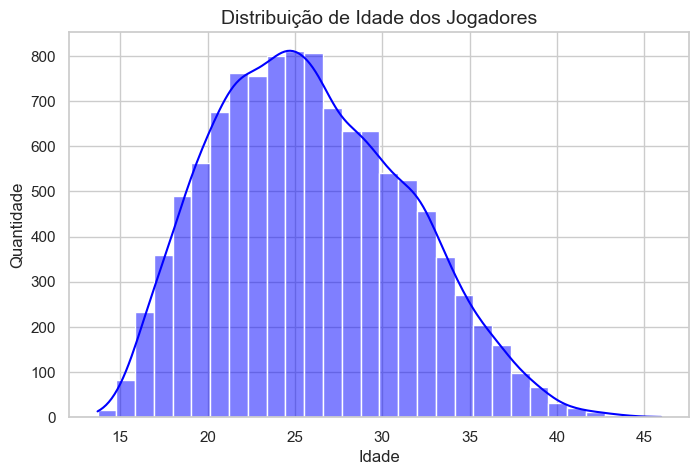

In [325]:
plt.figure(figsize=(8,5))

sns.histplot(
    jogadores['idade'],
    bins=30,
    kde=True,
    color='blue'
)

plt.title('Distribuição de Idade dos Jogadores', fontsize=14)
plt.xlabel('Idade')
plt.ylabel('Quantidade')
plt.savefig("assets/distribuicao_idade.png", dpi=150, bbox_inches="tight")
plt.show()


Altura

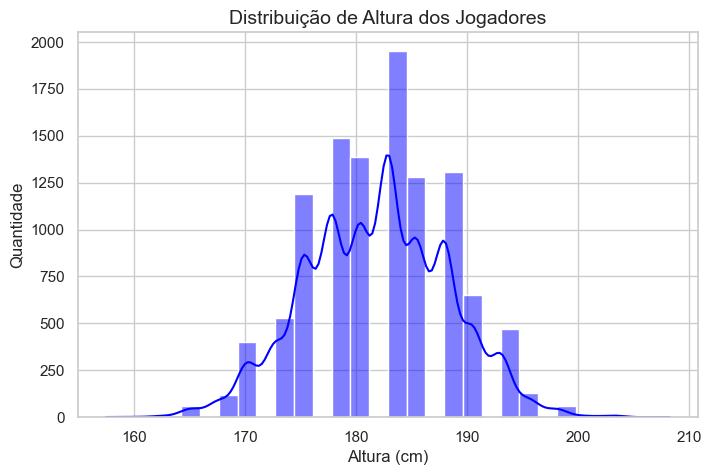

In [324]:
plt.figure(figsize=(8,5))

sns.histplot(
    jogadores['altura'],
    bins=30,
    kde=True,
    color='blue'
)

plt.title('Distribuição de Altura dos Jogadores', fontsize=14)
plt.xlabel('Altura (cm)')
plt.ylabel('Quantidade')
plt.savefig("assets/distribuicao_altura.png", dpi=150, bbox_inches="tight")
plt.show()

Peso

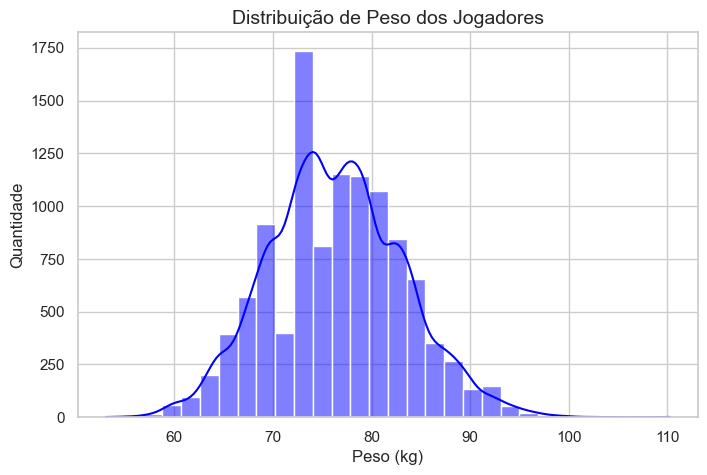

In [323]:
jogadores['peso_kg'] = jogadores['peso'] * 0.453592
plt.figure(figsize=(8,5))

sns.histplot(
    jogadores['peso_kg'],
    bins=30,
    kde=True,
    color='blue'
)

plt.title('Distribuição de Peso dos Jogadores', fontsize=14)
plt.xlabel('Peso (kg)')
plt.ylabel('Quantidade')
plt.savefig("assets/distribuicao_peso.png", dpi=150, bbox_inches="tight")
plt.show()

In [231]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


Estatísticas gerais

In [232]:
jogadores[['idade', 'altura', 'peso']].describe()

,idade,altura,peso
count,11060.000000,11060.000000,11060.000000
mean,25.926333,181.867445,168.380289
std,5.461620,6.369201,14.990217
min,13.701370,157.480000,117.000000
25%,21.739726,177.800000,159.000000
50%,25.504110,182.880000,168.000000
75%,29.816438,185.420000,179.000000
max,45.972603,208.280000,243.000000


IDENTIFICANDO OUTLIERS

In [234]:
jogadores['peso_kg'] = jogadores['peso'] * 0.453592


Jogadores muito altos

In [233]:
jogadores.sort_values(by='altura', ascending=False).head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5901,5908,148325,Kristof van Hout,185306,1987-02-09,208.28,243,25.912329,110.222856
11027,11043,30850,Zeljko Kalac,51883,1972-12-16,203.20,209,40.071233,94.800728
1298,1301,150209,Bogdan Milic,189967,1987-11-24,203.20,216,25.123288,97.975872
8273,8285,41129,Paolo Acerbis,137130,1981-05-05,203.20,190,31.682192,86.182480
5797,5804,96465,Kevin Vink,193674,1984-07-30,203.20,194,28.443836,87.996848


Jogadores muito baixos

In [235]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


jogadores muito pesados

In [236]:
jogadores.sort_values(by='peso_kg', ascending=False).head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
10297,10313,27313,Tim Wiese,53012,1981-12-17,193.04,243,31.063014,110.222856
5901,5908,148325,Kristof van Hout,185306,1987-02-09,208.28,243,25.912329,110.222856
4879,4884,5044,Jeroen Verhoeven,137692,1980-04-30,198.12,227,32.695890,102.965384
4408,4412,27267,Ishmael Miller,169725,1987-03-05,193.04,225,25.846575,102.058200
1595,1598,101584,Cassio,167958,1987-06-06,195.58,220,25.591781,99.790240


Correlação simples

In [237]:
jogadores[['idade', 'altura', 'peso']].corr()

,idade,altura,peso
idade,1.000000,0.061582,0.177161
altura,0.061582,1.000000,0.766626
peso,0.177161,0.766626,1.000000


In [238]:
jogadores[['idade', 'altura', 'peso_kg']].isna().sum()

idade      0
altura     0
peso_kg    0
dtype: int64

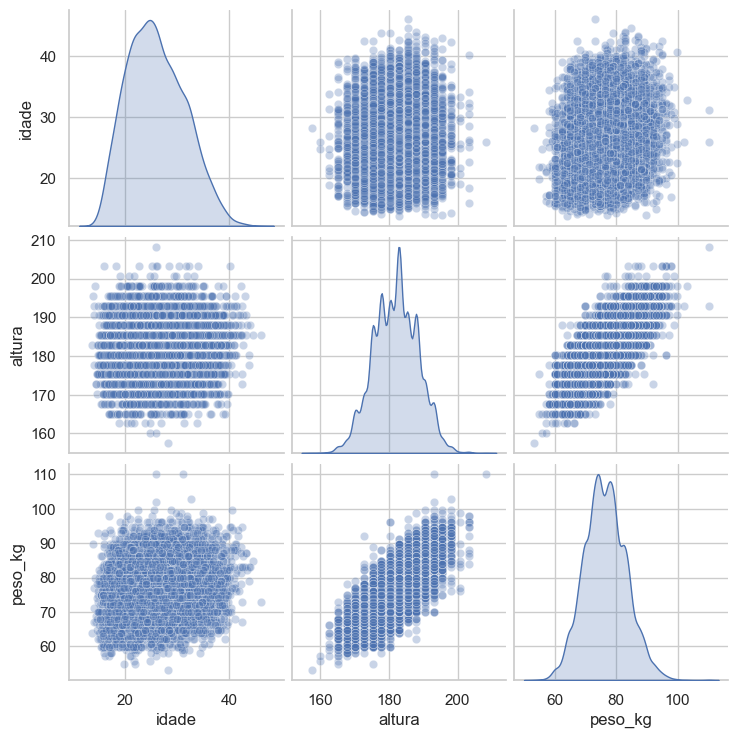

In [239]:
sns.pairplot(
    jogadores[['idade', 'altura', 'peso_kg']],
    diag_kind='kde',
    plot_kws={'alpha':0.3}
)

### Tabela League

In [241]:
ligas = pd.read_sql("SELECT * FROM League", conn)

In [242]:
ligas.head()
ligas.info

<bound method DataFrame.info of        id  country_id                      name
0       1           1    Belgium Jupiler League
1    1729        1729    England Premier League
2    4769        4769            France Ligue 1
3    7809        7809     Germany 1. Bundesliga
4   10257       10257             Italy Serie A
5   13274       13274    Netherlands Eredivisie
6   15722       15722        Poland Ekstraklasa
7   17642       17642  Portugal Liga ZON Sagres
8   19694       19694   Scotland Premier League
9   21518       21518           Spain LIGA BBVA
10  24558       24558  Switzerland Super League>

In [243]:
ligas.nunique()

id            11
country_id    11
name          11
dtype: int64

- Ligando nomes

In [244]:
ligas['name'].value_counts()

name
Belgium Jupiler League      1
England Premier League      1
France Ligue 1              1
Germany 1. Bundesliga       1
Italy Serie A               1
Netherlands Eredivisie      1
Poland Ekstraklasa          1
Portugal Liga ZON Sagres    1
Scotland Premier League     1
Spain LIGA BBVA             1
Switzerland Super League    1
Name: count, dtype: int64

- Relação com paises

In [245]:
paises = pd.read_sql("SELECT * FROM Country", conn)

Juntando as tabelas

In [247]:
ligas = ligas.merge(paises, left_on='country_id', right_on='id')


In [248]:
ligas = ligas.rename(columns={
    'name_x': 'liga',
    'name_y': 'pais'})


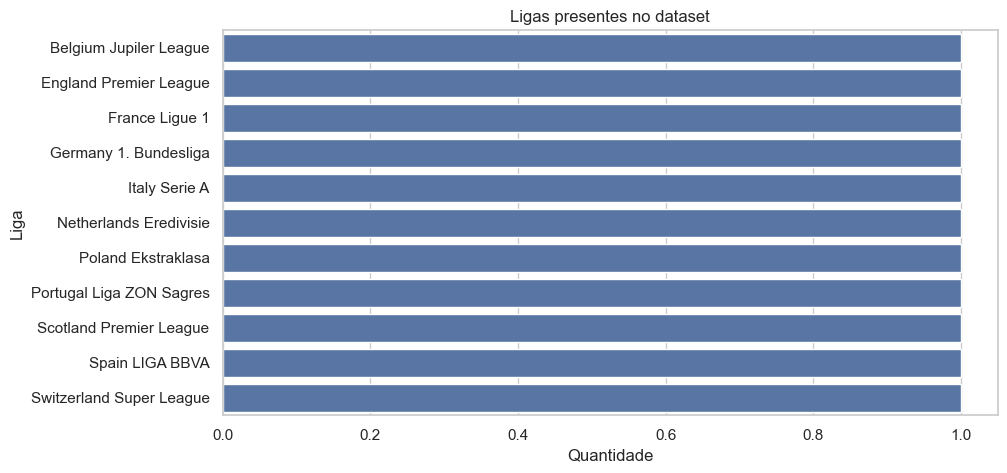

In [326]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=ligas['liga'],
    order=ligas['liga'].value_counts().index
    )

plt.title('Ligas presentes no dataset')

plt.xlabel('Quantidade')
plt.ylabel('Liga')
plt.show()



Vendo quantas ligas por pais

In [254]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


- Trazendo essas informações para os jogos

In [272]:
matches = matches.drop(
    columns=['liga_x', 'liga_y', 'pais_x', 'pais_y'],
    errors='ignore'
)

In [273]:
matches.columns

Index(['country_id', 'league_id', 'season', 'stage', 'date', 'match_api_id',
       'home_team_api_id', 'away_team_api_id', 'home_team_goal',
       'away_team_goal',
       ...
       'BSH', 'BSD', 'BSA', 'rating_mandante', 'rating_visitante',
       'diff_rating', 'resultado', 'id', 'liga', 'pais'],
      dtype='str', length=121)

Quantidade de jogos por liga

In [274]:
matches['liga'].value_counts()

liga
England Premier League      3040
France Ligue 1              3040
Spain LIGA BBVA             3040
Italy Serie A               3017
Germany 1. Bundesliga       2448
Netherlands Eredivisie      2448
Portugal Liga ZON Sagres    2052
Poland Ekstraklasa          1920
Scotland Premier League     1824
Belgium Jupiler League      1728
Switzerland Super League    1422
Name: count, dtype: int64

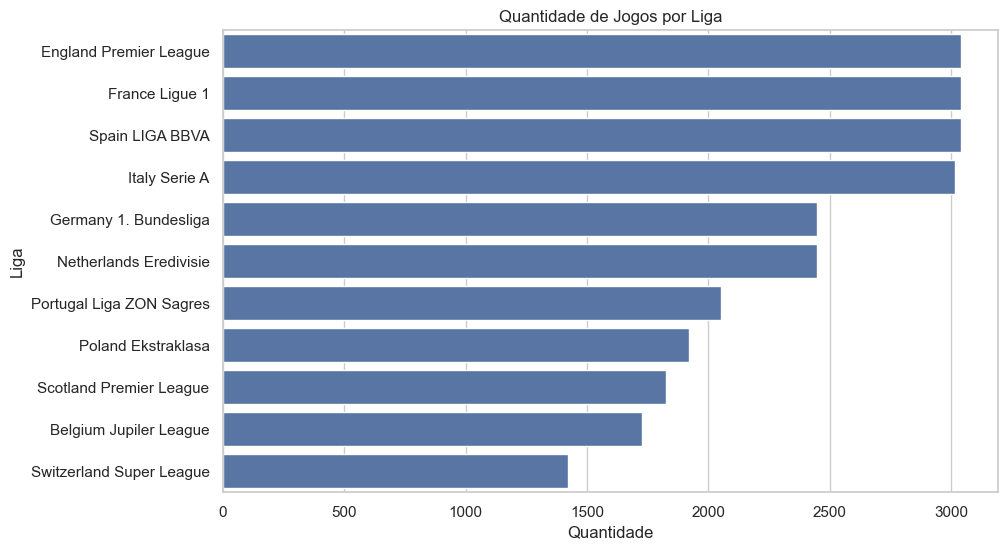

In [327]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=matches['liga'],
    order=matches['liga'].value_counts().index
)

plt.title('Quantidade de Jogos por Liga')
plt.xlabel('Quantidade')
plt.ylabel('Liga')
plt.savefig("assets/distribuicao_quantidade_jogos_liga.png", dpi=150, bbox_inches="tight")
plt.show()

Criando variaveis de gols totais

In [277]:

matches['gols_totais'] = (
    matches['home_team_goal'] + matches['away_team_goal']
)


In [278]:
matches[['home_team_goal', 'away_team_goal', 'gols_totais']].head()

,home_team_goal,away_team_goal,gols_totais
0,1,1,2
1,0,0,0
2,0,3,3
3,5,0,5
4,1,3,4


- Média de gols por liga

In [279]:
media_gols_liga = matches.groupby('liga')['gols_totais'].mean()
media_gols_liga = media_gols_liga.sort_values(ascending=False)
media_gols_liga

liga
Netherlands Eredivisie      3.080882
Switzerland Super League    2.929677
Germany 1. Bundesliga       2.901552
Belgium Jupiler League      2.801505
Spain LIGA BBVA             2.767105
England Premier League      2.710526
Scotland Premier League     2.633772
Italy Serie A               2.616838
Portugal Liga ZON Sagres    2.534600
France Ligue 1              2.443092
Poland Ekstraklasa          2.425000
Name: gols_totais, dtype: float64

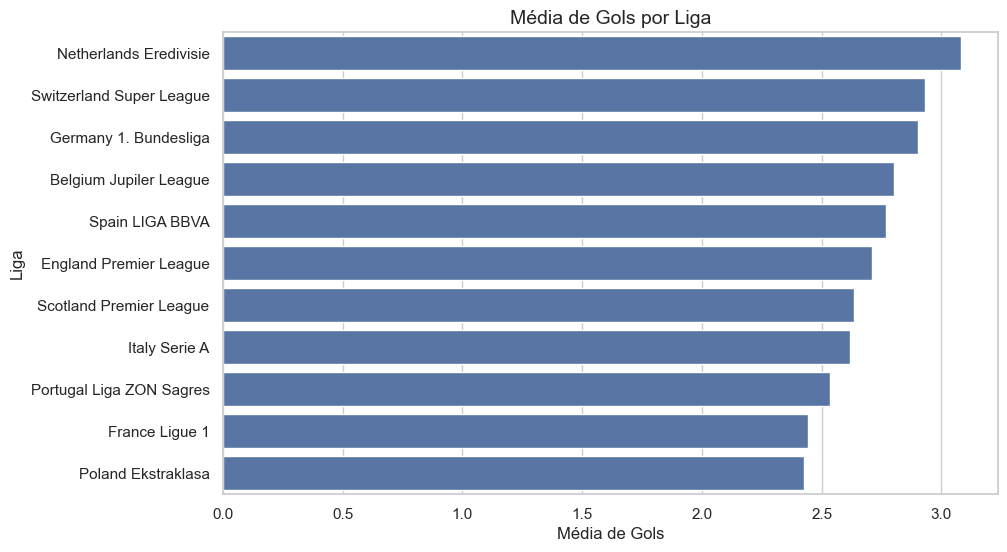

In [328]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=media_gols_liga.values,
    y=media_gols_liga.index
)

plt.title('Média de Gols por Liga', fontsize=14)
plt.xlabel('Média de Gols')
plt.ylabel('Liga')
plt.savefig("assets/media_gols_liga.png", dpi=150, bbox_inches="tight")
plt.show()

- ANÁLISE CASA vs FORA

In [281]:
media_gols = matches.groupby('liga')[[
    'home_team_goal',
    'away_team_goal'
]].mean()

media_gols

,home_team_goal,away_team_goal
liga,,
Belgium Jupiler League,1.609375,1.192130
England Premier League,1.550987,1.159539
France Ligue 1,1.402961,1.040132
Germany 1. Bundesliga,1.626634,1.274918
Italy Serie A,1.500829,1.116009
Netherlands Eredivisie,1.779820,1.301062
Poland Ekstraklasa,1.394792,1.030208
Portugal Liga ZON Sagres,1.408382,1.126218
Scotland Premier League,1.429276,1.204496


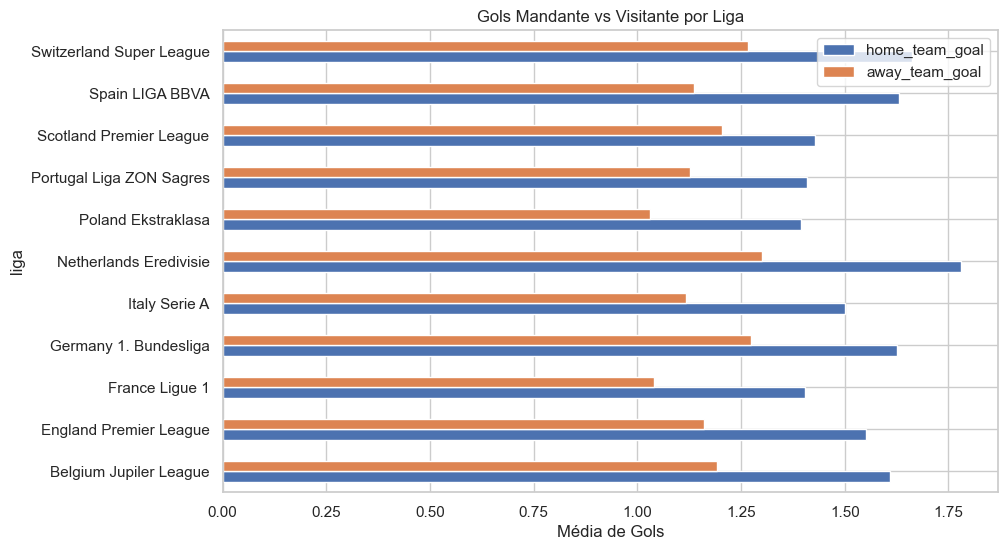

In [329]:

media_gols.plot(kind='barh', figsize=(10,6))

plt.title('Gols Mandante vs Visitante por Liga')
plt.xlabel('Média de Gols')
plt.savefig("assets/mandante_x_visitante_liga.png", dpi=150, bbox_inches="tight")
plt.show()


### Tabela Country

In [283]:
paises = pd.read_sql("SELECT * FROM Country", conn)

In [284]:
paises.head()
paises.info()
paises.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      11 non-null     int64
 1   name    11 non-null     str  
dtypes: int64(1), str(1)
memory usage: 308.0 bytes


id      11
name    11
dtype: int64

Renomeando

In [286]:
jogadores.sort_values(by='altura').head(5)

,id,id_jogador,nome_jogador,player_fifa_api_id,data_nascimento,altura,peso,idade,peso_kg
5446,5453,97226,Juan Quero,171126,1984-10-17,157.48,117,28.227397,53.070264
7247,7258,29587,Maxi Moralez,183895,1987-02-27,160.02,126,25.863014,57.152592
2609,2612,103139,Diego Buonanotte,170719,1988-04-19,160.02,123,24.720548,55.791816
3442,3446,215412,Fouad Rachid,201504,1991-11-15,162.56,126,21.145205,57.152592
2853,2857,278917,Edgar Salli,205753,1992-08-17,162.56,141,20.389041,63.956472


quantidade de jogos por pais

In [289]:
matches['pais'].value_counts()

pais
England        3040
France         3040
Spain          3040
Italy          3017
Germany        2448
Netherlands    2448
Portugal       2052
Poland         1920
Scotland       1824
Belgium        1728
Switzerland    1422
Name: count, dtype: int64

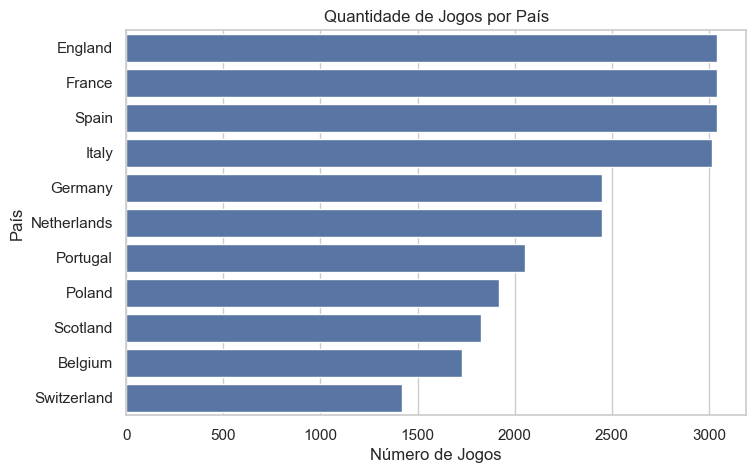

In [330]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=matches['pais'],
    order=matches['pais'].value_counts().index
)

plt.title('Quantidade de Jogos por País')
plt.xlabel('Número de Jogos')
plt.ylabel('País')
plt.savefig("assets/jogos_pais.png", dpi=150, bbox_inches="tight")
plt.show()

Média de gols por pais

In [291]:
media_gols_pais = matches.groupby('pais')['gols_totais'].mean()

media_gols_pais = media_gols_pais.sort_values(ascending=False)

media_gols_pais

pais
Netherlands    3.080882
Switzerland    2.929677
Germany        2.901552
Belgium        2.801505
Spain          2.767105
England        2.710526
Scotland       2.633772
Italy          2.616838
Portugal       2.534600
France         2.443092
Poland         2.425000
Name: gols_totais, dtype: float64

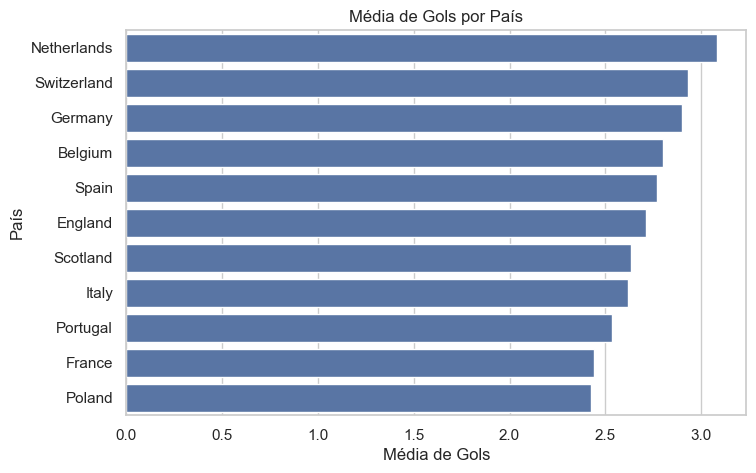

In [292]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=media_gols_pais.values,
    y=media_gols_pais.index
)

plt.title('Média de Gols por País')
plt.xlabel('Média de Gols')
plt.ylabel('País')

plt.show()

### Tabela Team

In [293]:
times = pd.read_sql("SELECT * FROM Team", conn)

In [294]:

times.head()
times.info()
times.nunique()


<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                299 non-null    int64  
 1   team_api_id       299 non-null    int64  
 2   team_fifa_api_id  288 non-null    float64
 3   team_long_name    299 non-null    str    
 4   team_short_name   299 non-null    str    
dtypes: float64(1), int64(2), str(2)
memory usage: 11.8 KB


id                  299
team_api_id         299
team_fifa_api_id    285
team_long_name      296
team_short_name     259
dtype: int64

Renomeando

In [295]:
times = times.rename(columns={
    'team_api_id': 'id_time',
    'team_long_name': 'nome_time'
})

In [297]:
# Ver quantos times existem
times['nome_time'].nunique()

296

In [298]:
times['nome_time'].value_counts().head()

nome_time
Royal Excel Mouscron    2
Polonia Bytom           2
Widzew Łódź             2
KRC Genk                1
Beerschot AC            1
Name: count, dtype: int64

Conectando com matches

In [299]:
matches = matches.merge(
    times[['id_time', 'nome_time']],
    left_on='home_team_api_id',
    right_on='id_time',
    how='left'
)

In [300]:
# renomear
matches = matches.rename(columns={
    'nome_time': 'time_mandante'
})

In [301]:
# times visitantes
matches = matches.merge(
    times[['id_time', 'nome_time']],
    left_on='away_team_api_id',
    right_on='id_time',
    how='left'
)

In [302]:
matches = matches.rename(columns={
    'nome_time': 'time_visitante'
})

Fazendo a limpeza

In [303]:
matches = matches.drop(columns=['id_time'], errors='ignore')

In [304]:
matches = matches.drop(columns=['id_time_x', 'id_time_y'], errors='ignore')

In [305]:
matches[['time_mandante', 'time_visitante']].head()

,time_mandante,time_visitante
0,KRC Genk,Beerschot AC
1,SV Zulte-Waregem,Sporting Lokeren
2,KSV Cercle Brugge,RSC Anderlecht
3,KAA Gent,RAEC Mons
4,FCV Dender EH,Standard de Liège


 - Analise simples

Times com mais jogos mandante

In [306]:
matches['time_mandante'].value_counts().head(10)

time_mandante
Manchester United    152
Arsenal              152
Sunderland           152
Aston Villa          152
Everton              152
Chelsea              152
Stoke City           152
Liverpool            152
Tottenham Hotspur    152
Manchester City      152
Name: count, dtype: int64

Times com mais jogos visitantes

In [307]:
matches['time_visitante'].value_counts().head(10)

time_visitante
Motherwell           153
Liverpool            152
Manchester City      152
Tottenham Hotspur    152
Stoke City           152
Everton              152
Chelsea              152
Sunderland           152
Aston Villa          152
Arsenal              152
Name: count, dtype: int64

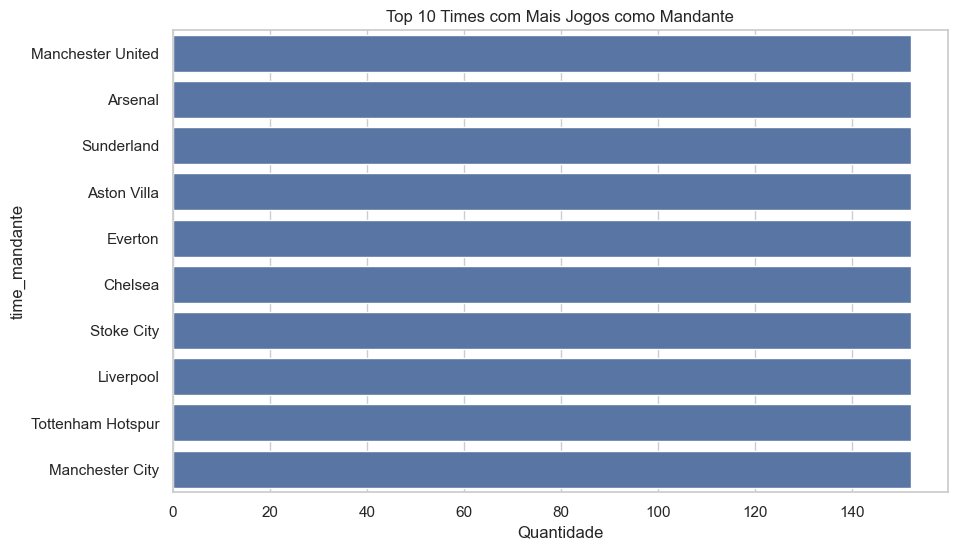

In [331]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=matches['time_mandante'],
    order=matches['time_mandante'].value_counts().head(10).index
)

plt.title('Top 10 Times com Mais Jogos como Mandante')
plt.xlabel('Quantidade')
plt.savefig("assets/top10_times_mandantes.png", dpi=150, bbox_inches="tight")
plt.show()